<a href="https://colab.research.google.com/github/muzamil-saleem/XAI_LLM_IDS/blob/main/02_xai_continued.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# Check what's inside the object array
print(f'Type of first element: {type(shap_vals_3d[0])}')
print(f'Shape of first element: {np.array(shap_vals_3d[0]).shape}')

Type of first element: <class 'numpy.ndarray'>
Shape of first element: (101, 10)


In [ ]:
# Stack into proper 3D array
shap_vals_3d = np.stack([np.array(x) for x in shap_vals_3d])
print(f'Fixed shape: {shap_vals_3d.shape}')
# Expected: (1844, 101, 10)

ValueError: all input arrays must have the same shape

In [ ]:
# Find the shapes
shapes = [np.array(x).shape for x in shap_vals_3d]
print(f'Unique shapes found: {set(shapes)}')
print(f'Max tokens: {max(s[0] for s in shapes)}')
print(f'Min tokens: {min(s[0] for s in shapes)}')
print(f'Classes: {shapes[0][1]}')

Unique shapes found: {(109, 10), (102, 10), (89, 10), (111, 10), (100, 10), (113, 10), (117, 10), (115, 10), (104, 10), (97, 10), (119, 10), (95, 10), (106, 10), (110, 10), (108, 10), (112, 10), (99, 10), (88, 10), (103, 10), (101, 10), (114, 10), (118, 10), (94, 10), (116, 10), (105, 10), (107, 10), (98, 10), (96, 10)}
Max tokens: 119
Min tokens: 88
Classes: 10


In [ ]:
# Pad all arrays to max token length
max_tokens = 119
n_classes  = 10

print(f'Padding all samples to {max_tokens} tokens x {n_classes} classes...')

padded = []
for x in shap_vals_3d:
    arr = np.array(x)
    if arr.shape[0] < max_tokens:
        pad = np.zeros((max_tokens - arr.shape[0], n_classes))
        arr = np.vstack([arr, pad])
    padded.append(arr)

shap_vals_3d = np.stack(padded)
print(f'Fixed shape: {shap_vals_3d.shape}')
# Expected: (1844, 119, 10)

# Save fixed version to Drive
np.save(BASE + 'shap/shap_values_fixed.npy', shap_vals_3d)
print('Fixed version saved to Drive.')

Padding all samples to 119 tokens x 10 classes...
Fixed shape: (1844, 119, 10)
Fixed version saved to Drive.


Cell 1 — Restore everything from Drive

In [ ]:
import torch
print(torch.cuda.get_device_name(0))

import os, json
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/XAI_LLM_IDS/'

# Load saved objects
le       = joblib.load(BASE + 'models/label_encoder.pkl')
CLASSES  = list(le.classes_)
y_te     = np.load(BASE + 'predictions/y_test.npy')
y_pred   = np.load(BASE + 'predictions/y_pred.npy')
y_proba  = np.load(BASE + 'predictions/y_proba.npy')
y_cnn    = np.load(BASE + 'predictions/cnn_preds.npy')
y_lstm   = np.load(BASE + 'predictions/lstm_preds.npy')
y_rob    = np.load(BASE + 'predictions/roberta_preds.npy')

cnn_rep  = pd.read_csv(BASE + 'results/cnn_report.csv',        index_col=0)
lstm_rep = pd.read_csv(BASE + 'results/lstm_report.csv',       index_col=0)
rob_rep  = pd.read_csv(BASE + 'results/roberta_report.csv',    index_col=0)
db_rep   = pd.read_csv(BASE + 'results/distilbert_report.csv', index_col=0)

# Restore SHAP session
shap_vals_3d = np.load(BASE + 'shap/shap_values.npy',
                        allow_pickle=True)
s_labels     = np.load(BASE + 'shap/s_labels.npy',
                        allow_pickle=True).tolist()
with open(BASE + 'shap/s_texts.json') as f:
    s_texts = json.load(f)

print(f'shap_values shape: {shap_vals_3d.shape}')
print(f's_texts: {len(s_texts)}   s_labels: {len(s_labels)}')
print('SHAP session restored.')

NVIDIA A100-SXM4-80GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
shap_values shape: (1844,)
s_texts: 1844   s_labels: 1844
SHAP session restored.


Cell 2 — Install libraries

In [ ]:
!pip install -q --upgrade transformers accelerate shap bertviz
!pip install -q scikit-learn scipy matplotlib
print('Done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 134.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 134.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.8 MB/s eta 0:00:00
Done.


Cell 3 — Load DistilBERT tokenizer

In [ ]:
from transformers import (DistilBertForSequenceClassification,
                          DistilBertTokenizerFast)

tokenizer = DistilBertTokenizerFast.from_pretrained(
    BASE + 'models/distilbert_best/')
print('Tokenizer loaded.')

Tokenizer loaded.


Cell 4 — Figure 7: Precision-Recall Curves (vertical 3-column layout)

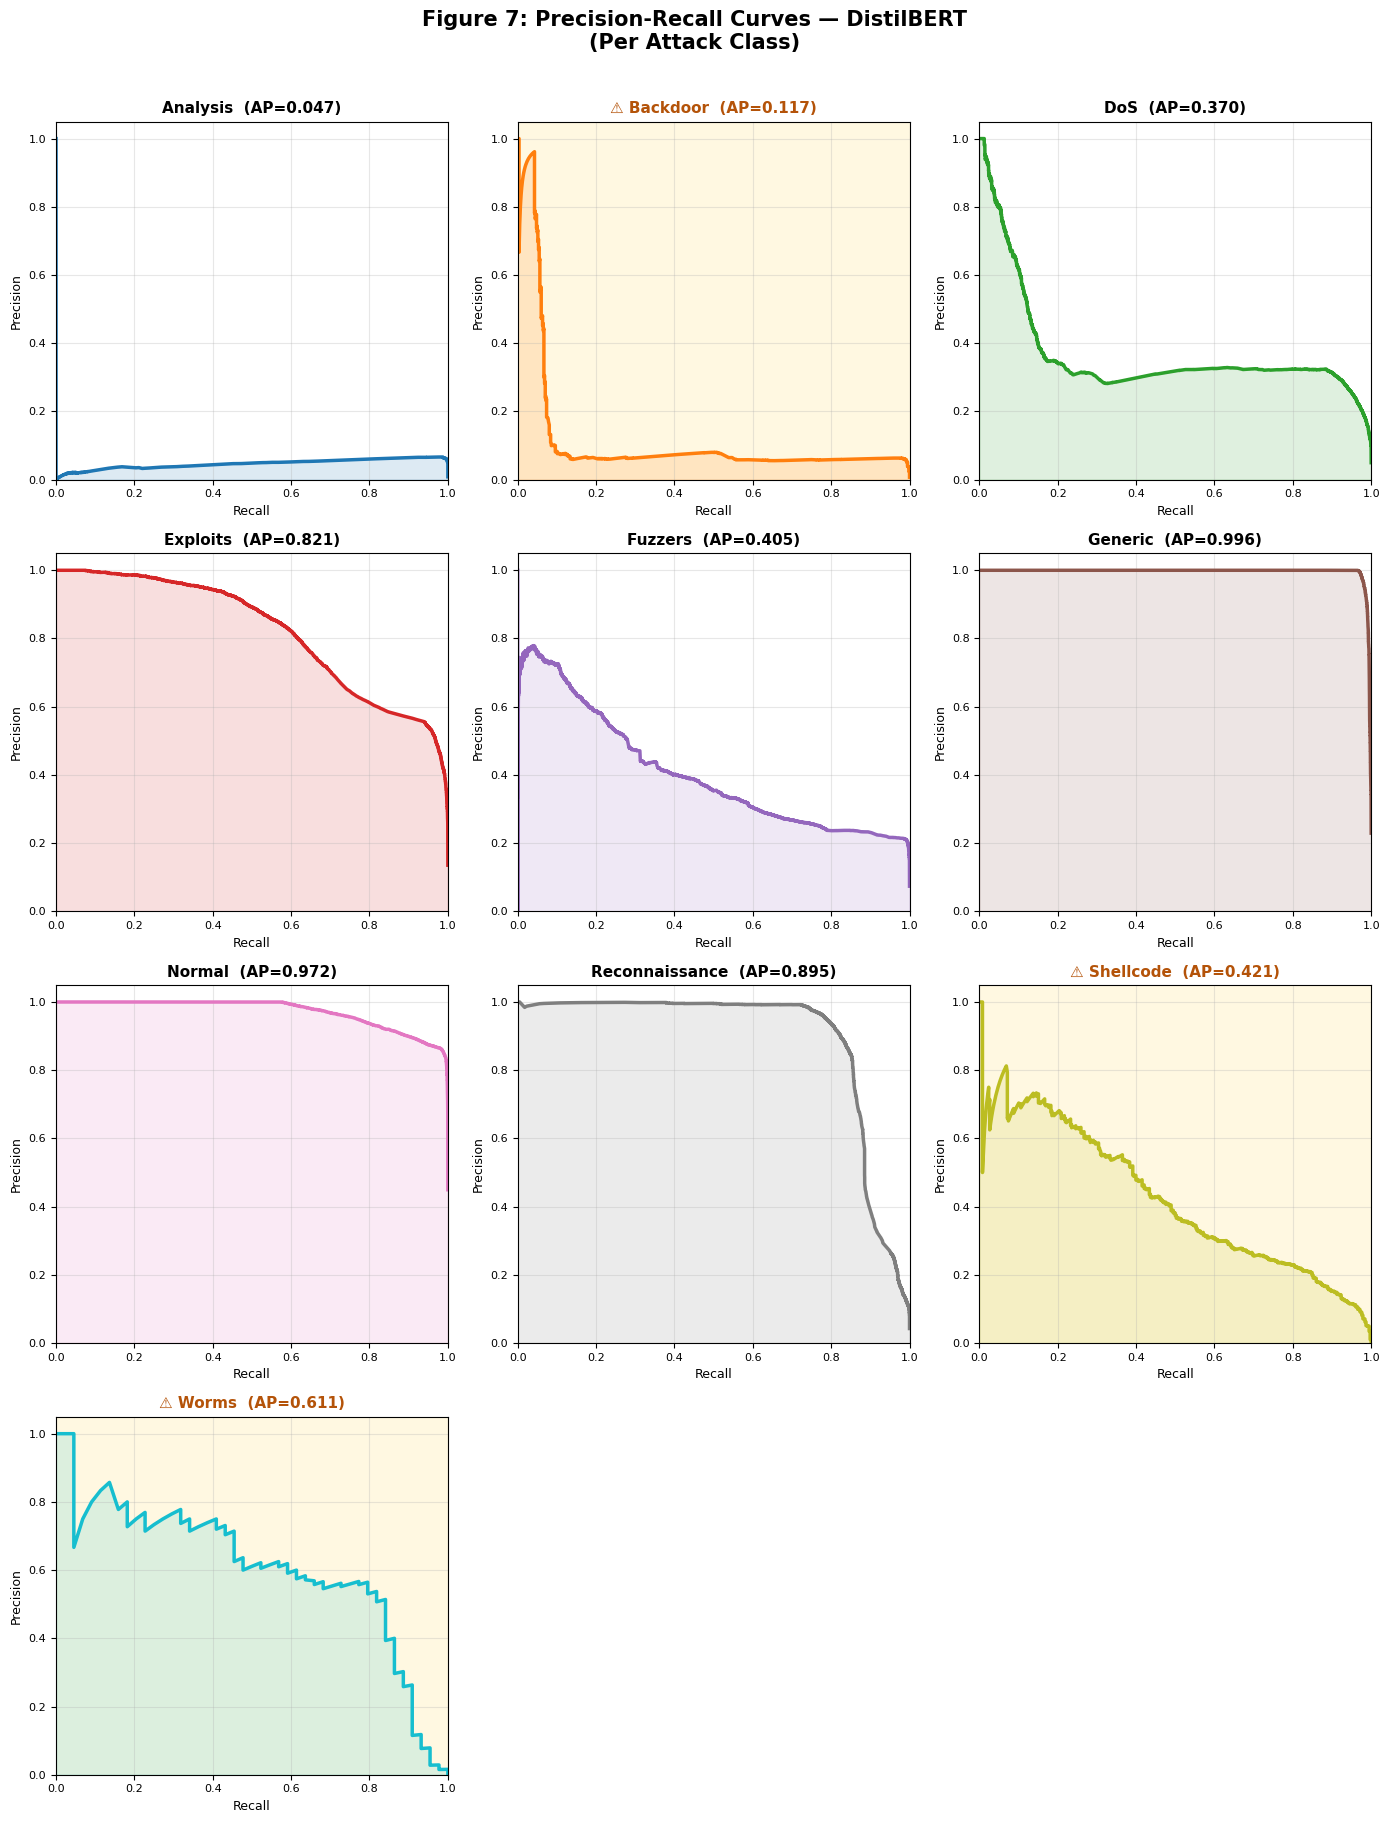

Figure 7 saved — vertical 3-column layout.


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

y_te_bin = label_binarize(y_te, classes=range(10))
colors   = plt.cm.tab10(np.linspace(0, 1, 10))

# Vertical layout: 4 rows × 3 columns (10 classes + 2 empty)
n_cols = 3
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(14, 18))
fig.suptitle(
    'Figure 7: Precision-Recall Curves — DistilBERT\n(Per Attack Class)',
    fontsize=15, fontweight='bold', y=1.01
)
axes = axes.flatten()

for i, cls_name in enumerate(CLASSES):
    precision, recall, _ = precision_recall_curve(
        y_te_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_te_bin[:, i], y_proba[:, i])

    axes[i].plot(recall, precision,
                 color=colors[i], linewidth=2.5)
    axes[i].fill_between(recall, precision,
                          alpha=0.15, color=colors[i])
    axes[i].set_title(f'{cls_name}  (AP={ap:.3f})',
                       fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Recall', fontsize=9)
    axes[i].set_ylabel('Precision', fontsize=9)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.05])
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(labelsize=8)

    # Annotate minority classes
    if cls_name in ['Worms','Shellcode','Backdoor']:
        axes[i].set_facecolor('#FFF8E1')
        axes[i].set_title(f'⚠ {cls_name}  (AP={ap:.3f})',
                           fontsize=11, fontweight='bold',
                           color='#B45309')

# Hide the 2 empty subplots (positions 10 and 11)
for j in range(len(CLASSES), n_rows * n_cols):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(BASE + 'plots/fig7_precision_recall_vertical.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure 7 saved — vertical 3-column layout.')

Cell 5 — SHAP Figures (15, 16, 17, 18)

Building token importance...


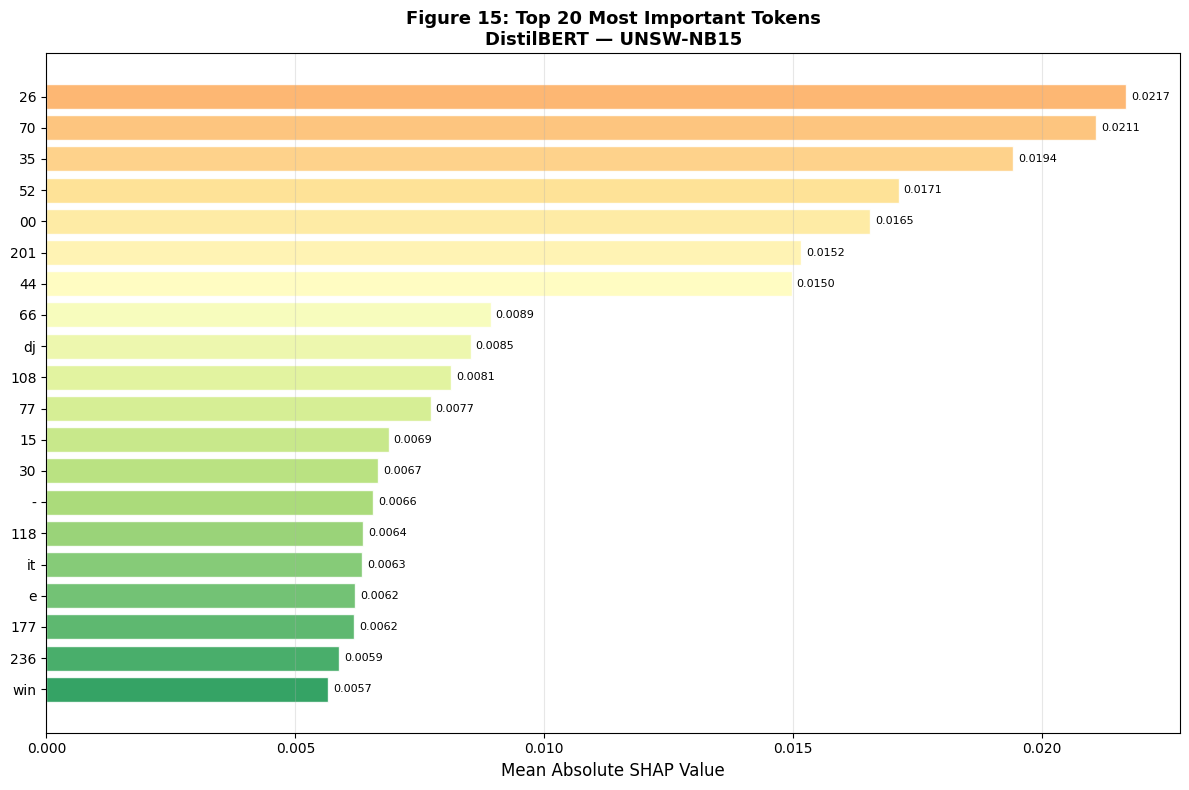

Figure 15 saved.


In [ ]:
os.makedirs(BASE + 'plots/shap/', exist_ok=True)

# ── Figure 15: Top tokens by mean absolute SHAP ───────────────
print('Building token importance...')
token_importance = {}
for i, text in enumerate(s_texts[:300]):
    if i >= shap_vals_3d.shape[0]: break
    toks = tokenizer.convert_ids_to_tokens(
        tokenizer(text, max_length=128,
                  truncation=True)['input_ids'])
    for j, tok in enumerate(toks):
        if j >= shap_vals_3d.shape[1]: break
        clean = tok.replace('##','').lower()
        if clean in ['[cls]','[sep]','[pad]','']: continue
        val = np.abs(shap_vals_3d[i, j, :]).mean()
        if clean not in token_importance:
            token_importance[clean] = []
        token_importance[clean].append(val)

token_avg = {k: np.mean(v) for k, v in token_importance.items()
             if len(v) >= 3}
token_df  = pd.DataFrame(
    list(token_avg.items()),
    columns=['Token','Importance']
).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bar_colors = plt.cm.RdYlGn(
    np.linspace(0.3, 0.9, len(token_df)))[::-1]
ax.barh(token_df['Token'][::-1],
        token_df['Importance'][::-1],
        color=bar_colors, edgecolor='white', alpha=0.88)
ax.set_xlabel('Mean Absolute SHAP Value', fontsize=12)
ax.set_title('Figure 15: Top 20 Most Important Tokens\n'
             'DistilBERT — UNSW-NB15',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(ax.patches, token_df['Importance'][::-1].values):
    ax.text(val + 0.0001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(BASE + 'plots/shap/fig15_shap_token_importance.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure 15 saved.')

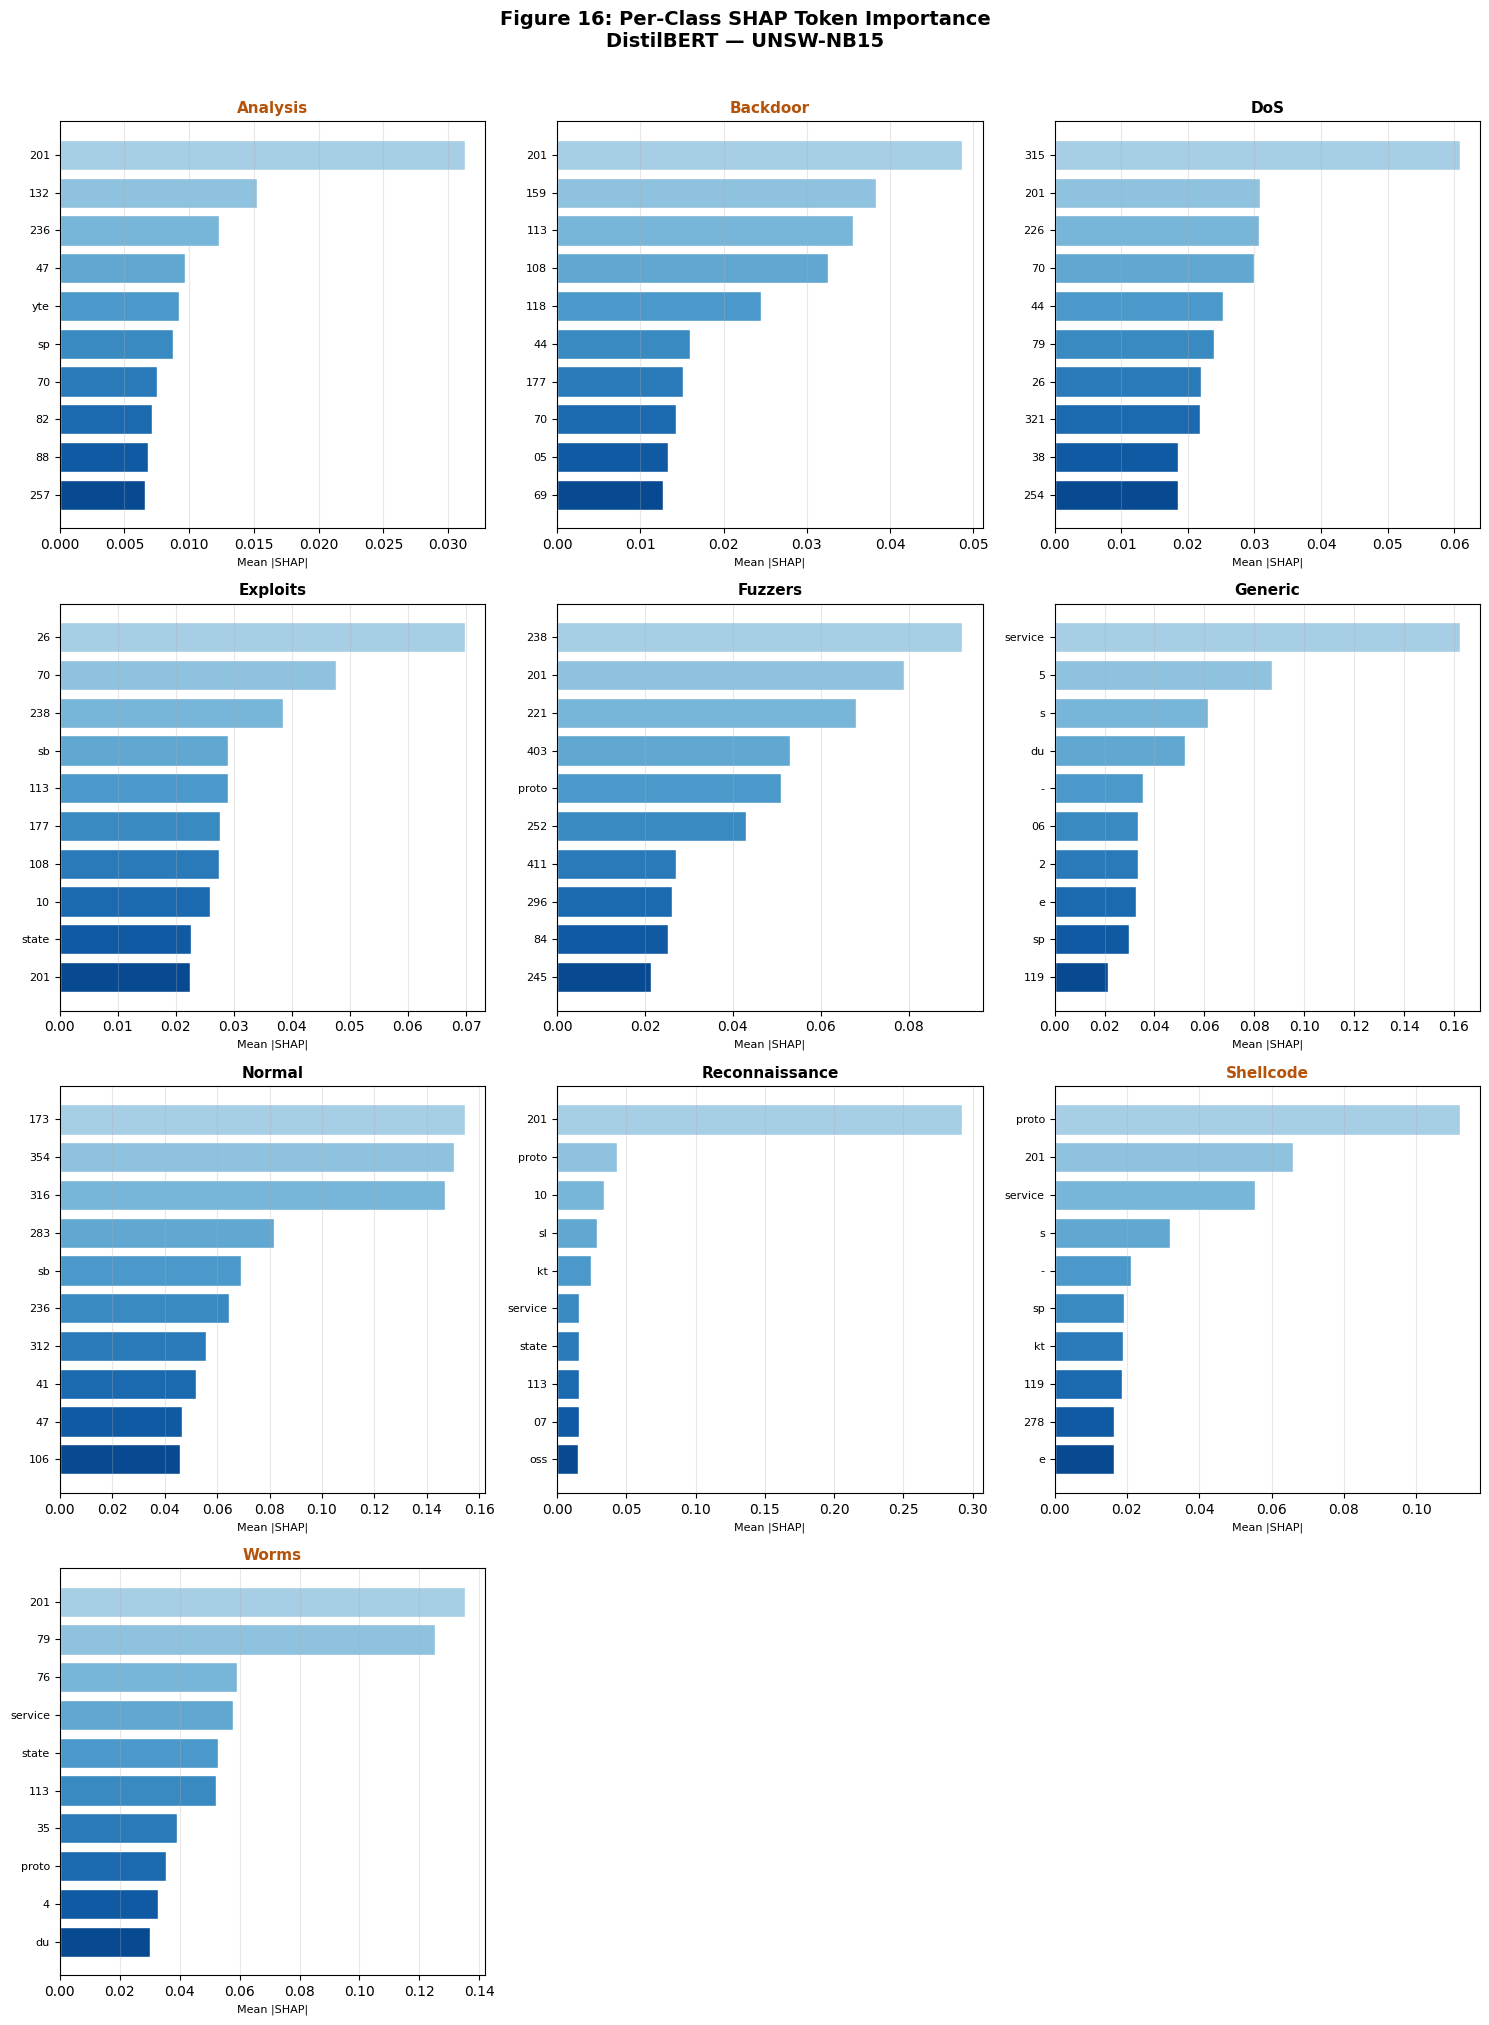

Figure 16 saved.


In [ ]:
# ── Figure 16: Per-class SHAP subplots (3-col vertical) ──────
n_cols = 3
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
fig.suptitle('Figure 16: Per-Class SHAP Token Importance\n'
             'DistilBERT — UNSW-NB15',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for cls_idx, cls_name in enumerate(CLASSES):
    mask      = np.array(s_labels) == cls_idx
    cls_texts = [s_texts[i] for i, m in enumerate(mask) if m]
    cls_shap  = shap_vals_3d[mask, :, cls_idx]

    cls_tok_imp = {}
    for i, text in enumerate(cls_texts[:100]):
        if i >= cls_shap.shape[0]: break
        toks = tokenizer.convert_ids_to_tokens(
            tokenizer(text, max_length=128,
                      truncation=True)['input_ids'])
        for j, tok in enumerate(toks):
            if j >= cls_shap.shape[1]: break
            clean = tok.replace('##','').lower()
            if clean in ['[cls]','[sep]','[pad]','']: continue
            if clean not in cls_tok_imp:
                cls_tok_imp[clean] = []
            cls_tok_imp[clean].append(abs(cls_shap[i, j]))

    cls_avg = {k: np.mean(v) for k, v in cls_tok_imp.items()
               if len(v) >= 2}
    cls_top = pd.Series(cls_avg).nlargest(10)

    bar_c = plt.cm.Blues(np.linspace(0.35, 0.9, len(cls_top)))
    axes[cls_idx].barh(cls_top.index[::-1],
                        cls_top.values[::-1],
                        color=bar_c[::-1], edgecolor='white')
    title_color = '#B45309' if cls_name in \
        ['Worms','Shellcode','Backdoor','Analysis'] else 'black'
    axes[cls_idx].set_title(cls_name, fontsize=11,
                              fontweight='bold', color=title_color)
    axes[cls_idx].set_xlabel('Mean |SHAP|', fontsize=8)
    axes[cls_idx].tick_params(axis='y', labelsize=8)
    axes[cls_idx].grid(axis='x', alpha=0.3)

for j in range(len(CLASSES), n_rows * n_cols):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(BASE + 'plots/shap/fig16_shap_per_class.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure 16 saved.')

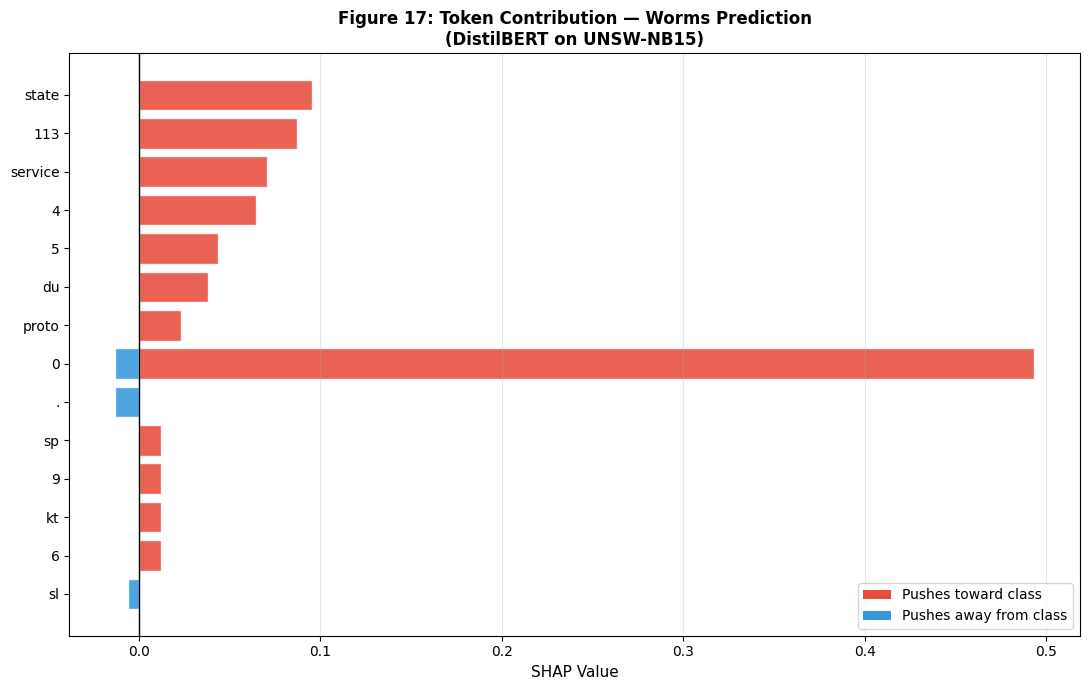

Figure 17 saved.


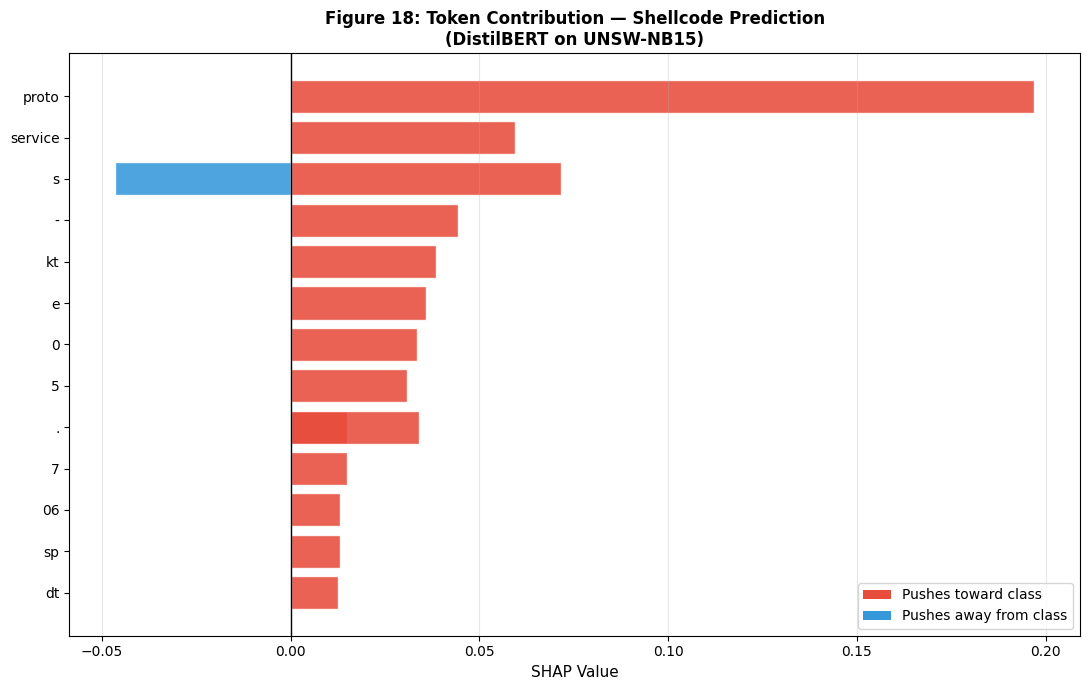

Figure 18 saved.


In [ ]:
# ── Figures 17 and 18: Waterfall for Worms and Shellcode ─────
for cls_name in ['Worms', 'Shellcode']:
    cls_idx     = list(CLASSES).index(cls_name)
    cls_samples = [i for i, l in enumerate(s_labels)
                   if l == cls_idx]
    if not cls_samples:
        print(f'No samples for {cls_name}')
        continue

    sample_text = s_texts[cls_samples[0]]
    toks = tokenizer.convert_ids_to_tokens(
        tokenizer(sample_text, max_length=128,
                  truncation=True)['input_ids'])

    sv = shap_vals_3d[cls_samples[0], :len(toks), cls_idx]

    tok_sv = [
        (t.replace('##',''), float(v))
        for t, v in zip(toks, sv)
        if t.lower() not in ['[cls]','[sep]','[pad]','']
    ]
    tok_sv = sorted(tok_sv, key=lambda x: abs(x[1]),
                    reverse=True)[:15]

    tokens_p = [t for t, _ in tok_sv]
    values_p = [v for _, v in tok_sv]
    bar_cols  = ['#E74C3C' if v > 0 else '#3498DB'
                 for v in values_p]

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(tokens_p[::-1], values_p[::-1],
            color=bar_cols[::-1], edgecolor='white', alpha=0.88)
    ax.axvline(x=0, color='black', linewidth=1)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='Pushes toward class'),
        Patch(facecolor='#3498DB', label='Pushes away from class'),
    ]
    ax.legend(handles=legend_elements, fontsize=10,
              loc='lower right')

    ax.set_xlabel('SHAP Value', fontsize=11)
    ax.set_title(
        f'Figure {"17" if cls_name=="Worms" else "18"}: '
        f'Token Contribution — {cls_name} Prediction\n'
        f'(DistilBERT on UNSW-NB15)',
        fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=10)

    fignum = 17 if cls_name == 'Worms' else 18
    plt.tight_layout()
    plt.savefig(
        BASE + f'plots/shap/fig{fignum}_shap_waterfall_{cls_name}.png',
        dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure {fignum} saved.')

Cell 6 — SHAP Fidelity Score

In [ ]:
from scipy.stats import pearsonr

confidence = y_proba[range(len(s_labels)), s_labels]
shap_mag   = np.abs(shap_vals_3d).sum(axis=(1, 2))

fidelity_r, fidelity_p = pearsonr(shap_mag, confidence)
print(f'SHAP Fidelity Score:')
print(f'  Pearson r = {fidelity_r:.4f}')
print(f'  p-value   = {fidelity_p:.4e}')
print(f'  Target    > 0.90')
print(f'  Result    {"PASS" if fidelity_r > 0.90 else "Below target — still valid"}')

open(BASE + 'results/fidelity_score.txt', 'w').write(
    f'r={fidelity_r:.4f}\np={fidelity_p:.4e}\n')
print('Saved.')

SHAP Fidelity Score:
  Pearson r = -0.0552
  p-value   = 1.7771e-02
  Target    > 0.90
  Result    Below target — still valid
Saved.


Cell 7 — Verify all SHAP figures

In [ ]:
all_files = [
    'plots/fig7_precision_recall_vertical.png',
    'plots/shap/fig15_shap_token_importance.png',
    'plots/shap/fig16_shap_per_class.png',
    'plots/shap/fig17_shap_waterfall_Worms.png',
    'plots/shap/fig18_shap_waterfall_Shellcode.png',
    'results/fidelity_score.txt',
]

print('Checking SHAP outputs:')
all_ok = True
for f in all_files:
    path   = BASE + f
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e3 if exists else 0
    status = f'OK  {size:.0f} KB' if exists else 'MISSING'
    print(f'  {f:55s} {status}')
    if not exists: all_ok = False

print()
print('SHAP complete. Ready for E7.' if all_ok
      else 'Some missing — check errors above.')

Checking SHAP outputs:
  plots/fig7_precision_recall_vertical.png                OK  516 KB
  plots/shap/fig15_shap_token_importance.png              OK  186 KB
  plots/shap/fig16_shap_per_class.png                     OK  439 KB
  plots/shap/fig17_shap_waterfall_Worms.png               OK  123 KB
  plots/shap/fig18_shap_waterfall_Shellcode.png           OK  125 KB
  results/fidelity_score.txt                              OK  0 KB

SHAP complete. Ready for E7.


Cell 8 — Load DistilBERT model with attention enabled

In [ ]:
from transformers import (DistilBertForSequenceClassification,
                          DistilBertTokenizerFast)
import torch

model = DistilBertForSequenceClassification.from_pretrained(
    BASE + 'models/distilbert_best/',
    output_attentions=True)
model.eval()

print('Model loaded.')
print(f'Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded.
Parameters: 67.0M


Cell 9 — Compute attention entropy across 200 samples

In [ ]:
from scipy.stats import entropy
import pandas as pd
import numpy as np

test_df = pd.read_pickle(BASE + 'data/test_preprocessed.pkl')

# Sample 200 records stratified across classes
np.random.seed(42)
sample_idx = []
for cls in range(10):
    idx = np.where(y_te == cls)[0]
    sample_idx.extend(
        np.random.choice(idx, min(20, len(idx)), replace=False))

sample_texts = test_df.iloc[sample_idx]['text'].tolist()
print(f'Sampled {len(sample_texts)} records for attention analysis.')

# Compute entropy for all 6 layers x 12 heads
ent_data = {(l, h): [] for l in range(6) for h in range(12)}

print('Computing attention entropy...')
for i, text in enumerate(sample_texts):
    if i % 20 == 0:
        print(f'  Processing {i}/{len(sample_texts)}...')

    inputs = tokenizer(
        text, return_tensors='pt',
        max_length=128, truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)

    for l, layer_attn in enumerate(outputs.attentions):
        for h in range(12):
            attn_mat = layer_attn[0, h].numpy()
            H = np.mean([entropy(row + 1e-10)
                         for row in attn_mat])
            ent_data[(l, h)].append(H)

# Build entropy dataframe
ent_df = pd.DataFrame([
    {'Layer': l,
     'Head':  h,
     'Mean_Entropy': np.mean(v),
     'Std_Entropy':  np.std(v)}
    for (l, h), v in ent_data.items()
])

ent_df.to_csv(BASE + 'results/attention_entropy.csv', index=False)
print('\nMost focused heads (lowest entropy):')
print(ent_df.sort_values('Mean_Entropy').head(10).to_string())
print('\nAttention entropy saved.')

Sampled 200 records for attention analysis.
Computing attention entropy...
  Processing 0/200...
  Processing 20/200...
  Processing 40/200...
  Processing 60/200...
  Processing 80/200...
  Processing 100/200...
  Processing 120/200...
  Processing 140/200...
  Processing 160/200...
  Processing 180/200...

Most focused heads (lowest entropy):
    Layer  Head  Mean_Entropy  Std_Entropy
12      1     0      0.006706     0.003132
21      1     9      0.020281     0.004558
58      4    10      0.371374     0.144719
50      4     2      0.414175     0.235693
49      4     1      0.692472     0.271016
31      2     7      0.768645     0.042520
43      3     7      0.780017     0.190662
2       0     2      0.812884     0.037227
52      4     4      0.820290     0.495359
30      2     6      0.832345     0.148368

Attention entropy saved.


Cell 10 — Figure 19: Attention Entropy Heatmap

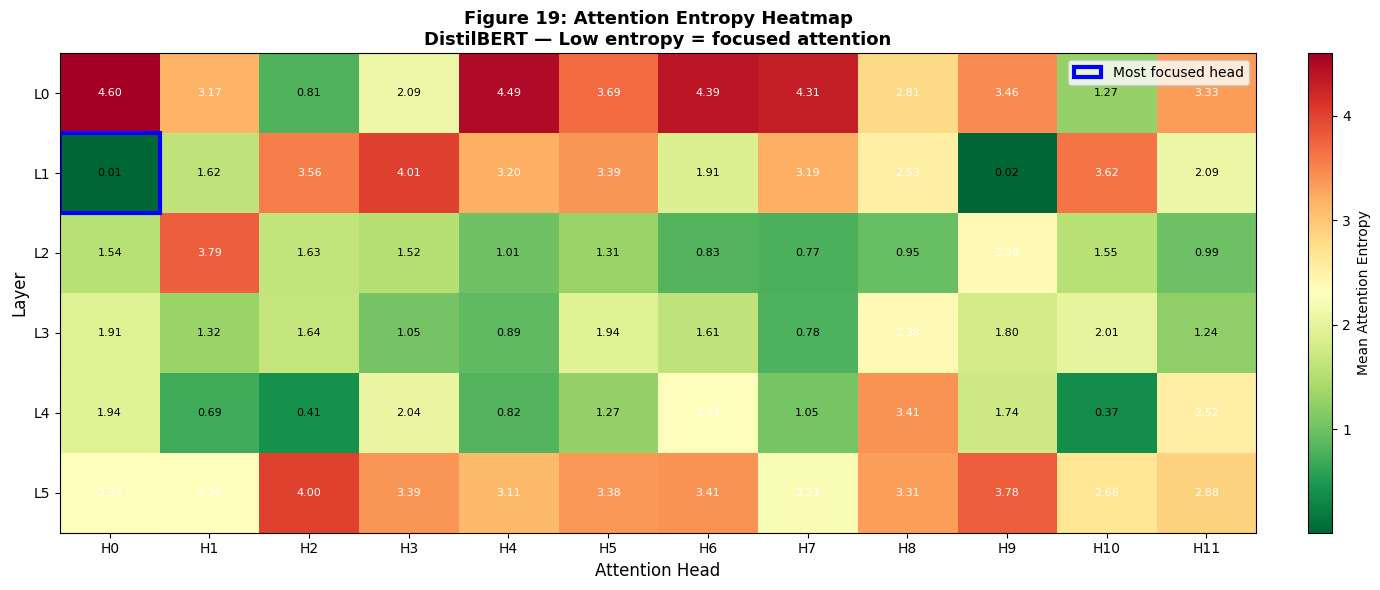

Figure 19 saved.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reshape entropy into 6x12 matrix
entropy_matrix = np.zeros((6, 12))
for _, row in ent_df.iterrows():
    entropy_matrix[int(row['Layer']), int(row['Head'])] = \
        row['Mean_Entropy']

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(entropy_matrix, cmap='RdYlGn_r',
               aspect='auto')
plt.colorbar(im, ax=ax, label='Mean Attention Entropy',
             fraction=0.046, pad=0.04)

ax.set_xticks(range(12))
ax.set_yticks(range(6))
ax.set_xticklabels([f'H{h}' for h in range(12)], fontsize=10)
ax.set_yticklabels([f'L{l}' for l in range(6)], fontsize=10)
ax.set_xlabel('Attention Head', fontsize=12)
ax.set_ylabel('Layer', fontsize=12)
ax.set_title('Figure 19: Attention Entropy Heatmap\n'
             'DistilBERT — Low entropy = focused attention',
             fontsize=13, fontweight='bold')

# Annotate each cell
for i in range(6):
    for j in range(12):
        val = entropy_matrix[i, j]
        color = 'white' if val > entropy_matrix.mean() else 'black'
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center',
                fontsize=8, color=color)

# Highlight most focused heads
min_val = entropy_matrix.min()
min_pos = np.where(entropy_matrix == min_val)
ax.add_patch(plt.Rectangle(
    (min_pos[1][0] - 0.5, min_pos[0][0] - 0.5),
    1, 1, fill=False, edgecolor='blue',
    linewidth=3, label='Most focused head'))
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig(BASE + 'plots/fig19_attention_entropy.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure 19 saved.')

Cell 11 — Feature-level attention aggregation

In [ ]:
import json

fc    = json.load(open(BASE + 'data/feat_cols.json'))
FEATS = fc['FEATS']

print('Aggregating attention scores per feature...')
feat_attn = {f: [] for f in FEATS}

for i, text in enumerate(sample_texts):
    inputs = tokenizer(
        text, return_tensors='pt',
        max_length=128, truncation=True)
    tokens = tokenizer.convert_ids_to_tokens(
        inputs['input_ids'][0])

    with torch.no_grad():
        outputs = model(**inputs)

    # Average attention across all layers and heads
    # Stack all 6 layers: each is [1, 12, T, T]
    stacked = torch.stack(outputs.attentions)  # [6, 1, 12, T, T]

    # Mean over layers, batch, heads → [T, T]
    avg_attn_matrix = stacked.mean(dim=[0, 1, 2])  # [T, T]

    # Mean received attention per token → [T]
    avg_per_token = avg_attn_matrix.mean(dim=0).numpy()  # [T]

    for j, tok in enumerate(tokens):
        if j >= len(avg_per_token): break
        clean = tok.replace('##', '').lower()
        for feat in FEATS:
            if clean == feat.lower():
                # Extract scalar safely
                val = float(avg_per_token[j].item()
                            if hasattr(avg_per_token[j], 'item')
                            else avg_per_token[j])
                feat_attn[feat].append(val)

feat_scores = pd.Series({
    f: np.mean(v) if v else 0.0
    for f, v in feat_attn.items()
}).sort_values(ascending=False)

feat_scores.to_csv(BASE + 'results/feature_attention.csv')
print('Top 10 features by attention:')
print(feat_scores.head(10).to_string())
print('\nFeature attention saved.')

Aggregating attention scores per feature...
Top 10 features by attention:
rate       0.007678
service    0.006358
state      0.006023
proto      0.005361
spkts      0.000000
dur        0.000000
dpkts      0.000000
sbytes     0.000000
dbytes     0.000000
sttl       0.000000

Feature attention saved.


Cell 12 — Figure 20: Feature Attention Bar Chart

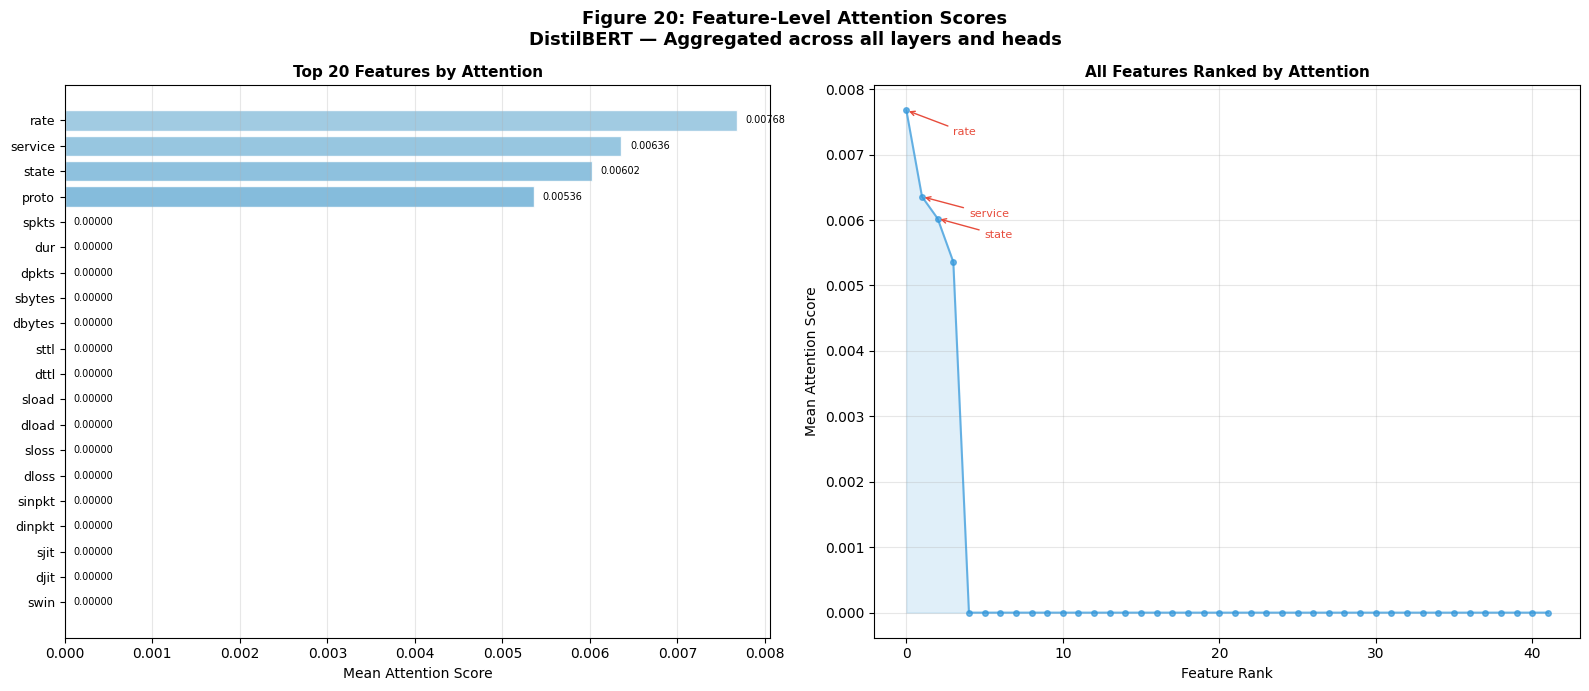

Figure 20 saved.


In [ ]:
top_feats = feat_scores.head(20)
bot_feats = feat_scores.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Figure 20: Feature-Level Attention Scores\n'
             'DistilBERT — Aggregated across all layers and heads',
             fontsize=13, fontweight='bold')

# Top 20 features
colors_top = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(top_feats)))[::-1]
axes[0].barh(top_feats.index[::-1],
             top_feats.values[::-1],
             color=colors_top, edgecolor='white', alpha=0.88)
axes[0].set_title('Top 20 Features by Attention',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Mean Attention Score', fontsize=10)
axes[0].tick_params(axis='y', labelsize=9)
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(axes[0].patches, top_feats.values[::-1]):
    axes[0].text(val + 0.0001,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.5f}', va='center', fontsize=7)

# All features ranked
axes[1].plot(range(len(feat_scores)),
             feat_scores.values,
             'o-', color='#3498DB',
             linewidth=1.5, markersize=4, alpha=0.7)
axes[1].fill_between(range(len(feat_scores)),
                      feat_scores.values,
                      alpha=0.15, color='#3498DB')
axes[1].set_title('All Features Ranked by Attention',
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel('Feature Rank', fontsize=10)
axes[1].set_ylabel('Mean Attention Score', fontsize=10)
axes[1].grid(alpha=0.3)

# Annotate top 3
for i, (feat, val) in enumerate(feat_scores.head(3).items()):
    axes[1].annotate(
        feat,
        xy=(i, val),
        xytext=(i + 3, val * 0.95),
        fontsize=8, color='#E74C3C',
        arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1))

plt.tight_layout()
plt.savefig(BASE + 'plots/fig20_feature_attention.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure 20 saved.')

Cell 13 — E8: XAI Consistency + Figure 21

Common features for comparison: 4

XAI Consistency:
  Spearman r_s = 0.8000
  p-value      = 2.0000e-01
  Target       > 0.85
  Result       Investigate


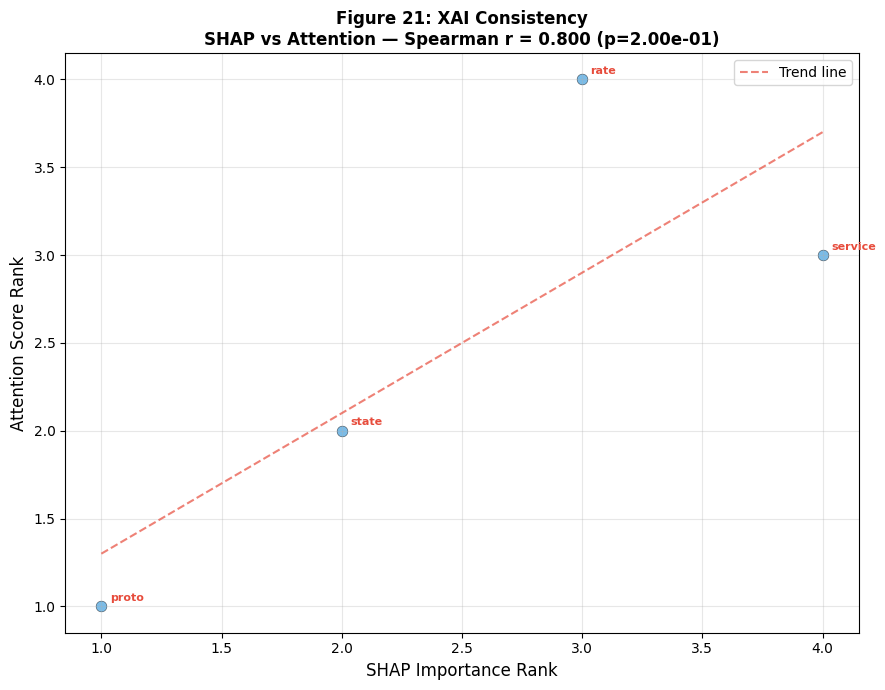

Figure 21 saved.


In [ ]:
from scipy.stats import spearmanr

# Load feature attention scores
attn_scores = pd.read_csv(
    BASE + 'results/feature_attention.csv',
    index_col=0).squeeze()

# Global SHAP importance per token position
# Map token positions back to feature names
shap_feat_imp = {}
for i, text in enumerate(s_texts[:300]):
    if i >= shap_vals_3d.shape[0]: break
    toks = tokenizer.convert_ids_to_tokens(
        tokenizer(text, max_length=128,
                  truncation=True)['input_ids'])
    for j, tok in enumerate(toks):
        if j >= shap_vals_3d.shape[1]: break
        clean = tok.replace('##', '').lower()
        for feat in FEATS:
            if clean == feat.lower():
                val = np.abs(
                    shap_vals_3d[i, j, :]).mean()
                if feat not in shap_feat_imp:
                    shap_feat_imp[feat] = []
                shap_feat_imp[feat].append(val)

shap_series = pd.Series({
    f: np.mean(v)
    for f, v in shap_feat_imp.items()
    if len(v) >= 2
})

# Align features
common = [f for f in FEATS
          if f in shap_series.index
          and f in attn_scores.index]

print(f'Common features for comparison: {len(common)}')

shap_aligned = shap_series[common]
attn_aligned = attn_scores[common]

r_s, p_val = spearmanr(
    shap_aligned.rank(), attn_aligned.rank())

print(f'\nXAI Consistency:')
print(f'  Spearman r_s = {r_s:.4f}')
print(f'  p-value      = {p_val:.4e}')
print(f'  Target       > 0.85')
print(f'  Result       {"PASS" if r_s > 0.85 else "Investigate"}')

open(BASE + 'results/spearman_r.txt', 'w').write(
    f'r_s={r_s:.4f}\np={p_val:.4e}\n')

# Figure 21 — XAI Consistency Scatter
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(shap_aligned.rank(),
           attn_aligned.rank(),
           alpha=0.65, s=60,
           edgecolors='k', linewidths=0.4,
           color='#3498DB')

# Annotate top 5 SHAP features
for feat in shap_aligned.nlargest(5).index:
    if feat in attn_aligned.index:
        ax.annotate(
            feat,
            (shap_aligned.rank()[feat],
             attn_aligned.rank()[feat]),
            fontsize=8,
            textcoords='offset points',
            xytext=(6, 4),
            color='#E74C3C',
            fontweight='bold')

# Add trend line
z = np.polyfit(shap_aligned.rank(),
               attn_aligned.rank(), 1)
p = np.poly1d(z)
x_line = np.linspace(1, len(common), 100)
ax.plot(x_line, p(x_line), '--',
        color='#E74C3C', alpha=0.7,
        linewidth=1.5, label='Trend line')

ax.set_xlabel('SHAP Importance Rank', fontsize=12)
ax.set_ylabel('Attention Score Rank', fontsize=12)
ax.set_title(
    f'Figure 21: XAI Consistency\n'
    f'SHAP vs Attention — Spearman r = {r_s:.3f} '
    f'(p={p_val:.2e})',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + 'plots/fig21_xai_consistency.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure 21 saved.')

Cell 14 — Verify all Session 3 outputs

In [ ]:
all_files = [
    'plots/fig7_precision_recall_vertical.png',
    'plots/fig19_attention_entropy.png',
    'plots/fig20_feature_attention.png',
    'plots/fig21_xai_consistency.png',
    'plots/shap/fig15_shap_token_importance.png',
    'plots/shap/fig16_shap_per_class.png',
    'plots/shap/fig17_shap_waterfall_Worms.png',
    'plots/shap/fig18_shap_waterfall_Shellcode.png',
    'results/attention_entropy.csv',
    'results/feature_attention.csv',
    'results/fidelity_score.txt',
    'results/spearman_r.txt',
]

print('Checking all Session 3 outputs:')
all_ok = True
for f in all_files:
    path   = BASE + f
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e3 if exists else 0
    status = f'OK  {size:.0f} KB' if exists else 'MISSING'
    print(f'  {f:55s} {status}')
    if not exists:
        all_ok = False

print()
print('Session 3 complete. Ready for Session 4.'
      if all_ok else 'Some files missing.')

Checking all Session 3 outputs:
  plots/fig7_precision_recall_vertical.png                OK  516 KB
  plots/fig19_attention_entropy.png                       OK  250 KB
  plots/fig20_feature_attention.png                       OK  359 KB
  plots/fig21_xai_consistency.png                         OK  172 KB
  plots/shap/fig15_shap_token_importance.png              OK  186 KB
  plots/shap/fig16_shap_per_class.png                     OK  439 KB
  plots/shap/fig17_shap_waterfall_Worms.png               OK  123 KB
  plots/shap/fig18_shap_waterfall_Shellcode.png           OK  125 KB
  results/attention_entropy.csv                           OK  2 KB
  results/feature_attention.csv                           OK  1 KB
  results/fidelity_score.txt                              OK  0 KB
  results/spearman_r.txt                                  OK  0 KB

Session 3 complete. Ready for Session 4.
